In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("smartcart_customers.csv")

In [8]:
import os

os.getcwd()


'C:\\Users\\lenovo\\Desktop\\Prime Classes\\SmartCart_Clustering-_System'

In [4]:
import os

os.chdir(r"C:\Users\lenovo\Desktop\Prime Classes\SmartCart_Clustering-_System")


In [5]:
os.getcwd()


'C:\\Users\\lenovo\\Desktop\\Prime Classes\\SmartCart_Clustering-_System'

In [6]:
os.listdir()


['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'smartcart_customers.csv',
 'Untitled.ipynb']

In [9]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [10]:
df.shape

(2240, 22)

In [12]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# data preproseccing


## 1. Handle missing value : Missing values in the Income column are replaced using the median income. Median imputation is chosen because income can contain extreme values/outliers, and the median is less sensitive to such values than the mean.

In [13]:
df["Income"]= df["Income"].fillna(df["Income"].median())

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Feature Engineering

In [15]:
# Age 
df["Age"] = 2026-df["Year_Birth"]

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [19]:
# customer joining date
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"], dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [20]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [21]:
df.columns



Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [22]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"]+ df["MntMeatProducts"]+ df["MntFishProducts"] + df["MntSweetProducts"]+ df["MntGoldProds"]

In [24]:
# children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [27]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate", "2n Cycle": "Undergraduate","Graduation":"Graduate", "Master":"Postgraduate", "PHD":"Postgraduate"})



# undergraduate , graduate, postgraduate

In [28]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [35]:
# mariatal status


df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner", "Together": "Partner",
    "Single":"Alone", "Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"})


df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [36]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [44]:
cols = ["ID","Year_Birth","Marital_Status", "Kidhome"
        ,"Teenhome","Dt_Customer"]
spending_cols = ["MntWines", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns = cols_to_drop)

In [45]:
df_cleaned.shape

(2240, 16)

In [46]:
df.shape

(2240, 27)

In [47]:
df_cleaned.head

<bound method NDFrame.head of          Education   Income  Recency  MntFruits  NumDealsPurchases  \
0         Graduate  58138.0       58         88                  3   
1         Graduate  46344.0       38          1                  2   
2         Graduate  71613.0       26         49                  1   
3         Graduate  26646.0       26          4                  2   
4              PhD  58293.0       94         43                  5   
...            ...      ...      ...        ...                ...   
2235      Graduate  61223.0       46         43                  2   
2236           PhD  64014.0       56          0                  7   
2237      Graduate  56981.0       91         48                  1   
2238  Postgraduate  69245.0        8         30                  2   
2239           PhD  52869.0       40          3                  3   

      NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
0                   8                   10                  4   

# Outlier

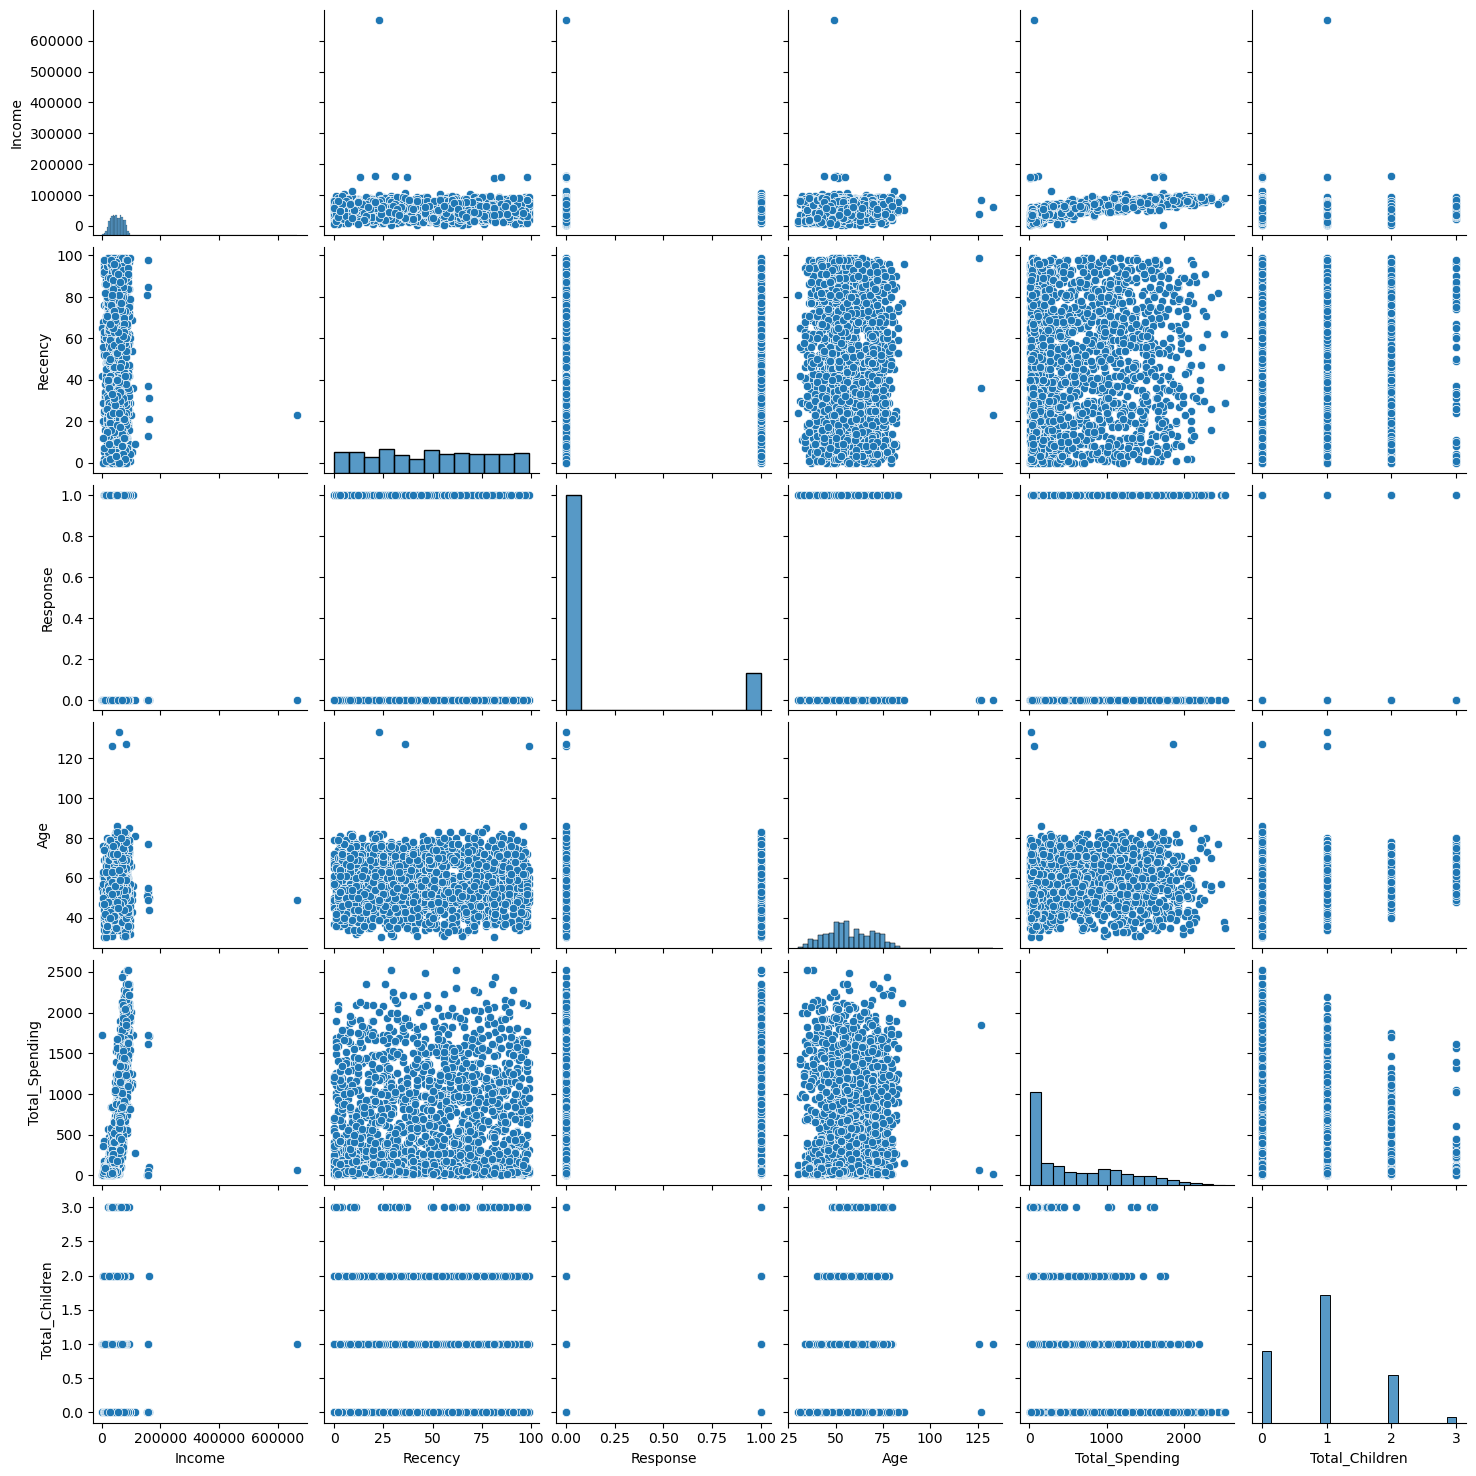

In [50]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

#relative plots of some features pair plots
sns.pairplot(df_cleaned[cols])

# remove outliers

In [53]:
print("data size with outliers:", len(df_cleaned))

def_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
def_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("data size without outlier:", len(df_cleaned))

data size with outliers: 2240
data size without outlier: 2240


##Heatmap

In [54]:
corr = df_cleaned.corr(numeric_only= True)

<Axes: >

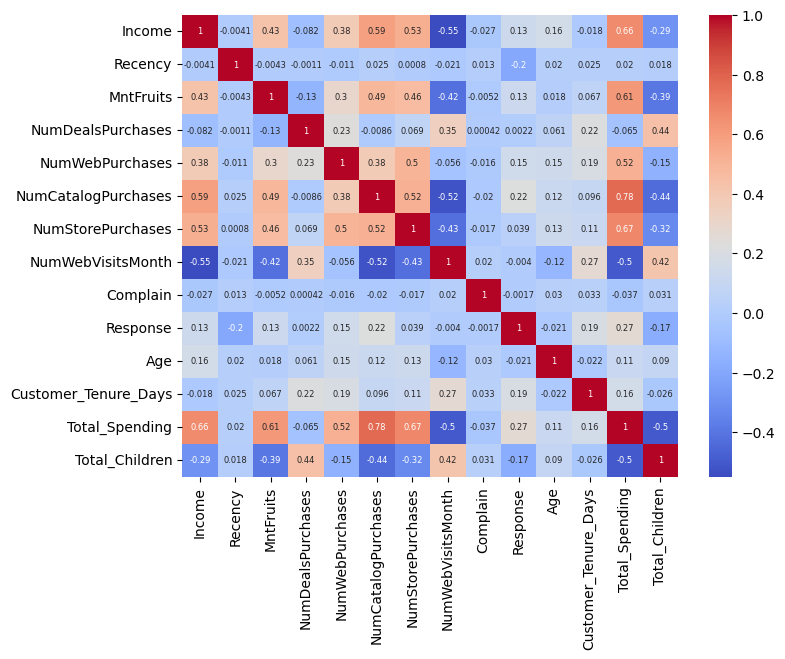

In [55]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot= True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

In [56]:
df_cleaned.shape

(2240, 16)

In [57]:
df_cleaned.head()

,Education,Income,Recency,MntFruits,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,88,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,1,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,49,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,4,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PhD,58293.0,94,43,5,5,3,6,5,0,0,45,161,422,1,Partner


##Encoding

In [58]:
from  sklearn.preprocessing import OneHotEncoder

In [59]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [60]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns= ohe.get_feature_names_out(cat_cols), index= df_cleaned.index)


In [61]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [62]:
df_encoded.shape

(2240, 20)

In [63]:
df_encoded.head

<bound method NDFrame.head of        Income  Recency  MntFruits  NumDealsPurchases  NumWebPurchases  \
0     58138.0       58         88                  3                8   
1     46344.0       38          1                  2                1   
2     71613.0       26         49                  1                8   
3     26646.0       26          4                  2                2   
4     58293.0       94         43                  5                5   
...       ...      ...        ...                ...              ...   
2235  61223.0       46         43                  2                9   
2236  64014.0       56          0                  7                8   
2237  56981.0       91         48                  1                2   
2238  69245.0        8         30                  2                6   
2239  52869.0       40          3                  3                3   

      NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
0               

In [69]:
##Scalling

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
X = df_encoded

In [66]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Visualize

In [70]:
X_scaled.shape

(2240, 20)

In [71]:
#2d
from sklearn.decomposition import PCA

In [72]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

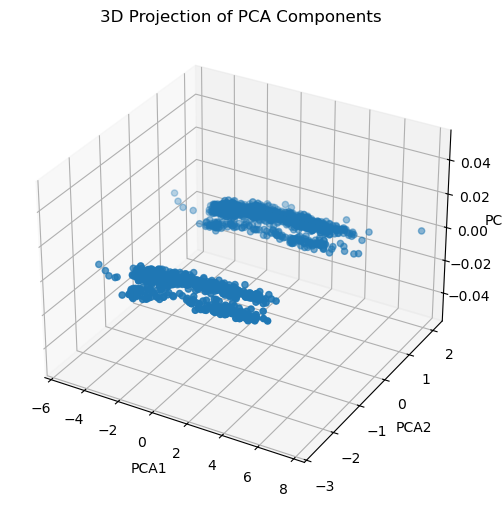

In [82]:
# plot

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
)

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection of PCA Components")

plt.show()


##Analyze K value